#  Image Classifier (Dogs vs Cats)
Este notebook entrena una CNN con `ImageDataGenerator.flow_from_directory` usando el dataset organizado en:

- `data/raw/train/cat` y `data/raw/train/dog`
- `data/raw/test/cat` y `data/raw/test/dog`

> Nota: el notebook funciona tanto si se ejecuta desde la raíz del repo como desde `/src` (auto-detecta rutas).

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping
from pathlib import Path
import matplotlib.pyplot as plt


2026-02-02 17:58:42.240606: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-02 17:58:42.240931: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-02 17:58:42.317035: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-02 17:58:44.259365: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [2]:
# Rutas
TRAIN_DIR = Path("../data/raw/train")
TEST_DIR = Path("../data/raw/test")

# Parámetros
IMG_SIZE = (160, 160)
BATCH_SIZE = 8
EPOCHS = 5


In [3]:
# ===============================
# GENERADORES DE DATOS
# ===============================

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_data = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)


Found 16000 images belonging to 2 classes.
Found 4000 images belonging to 2 classes.


Se muestran algunas imágenes del conjunto de entrenamiento para verificar la correcta carga y etiquetado del dataset.

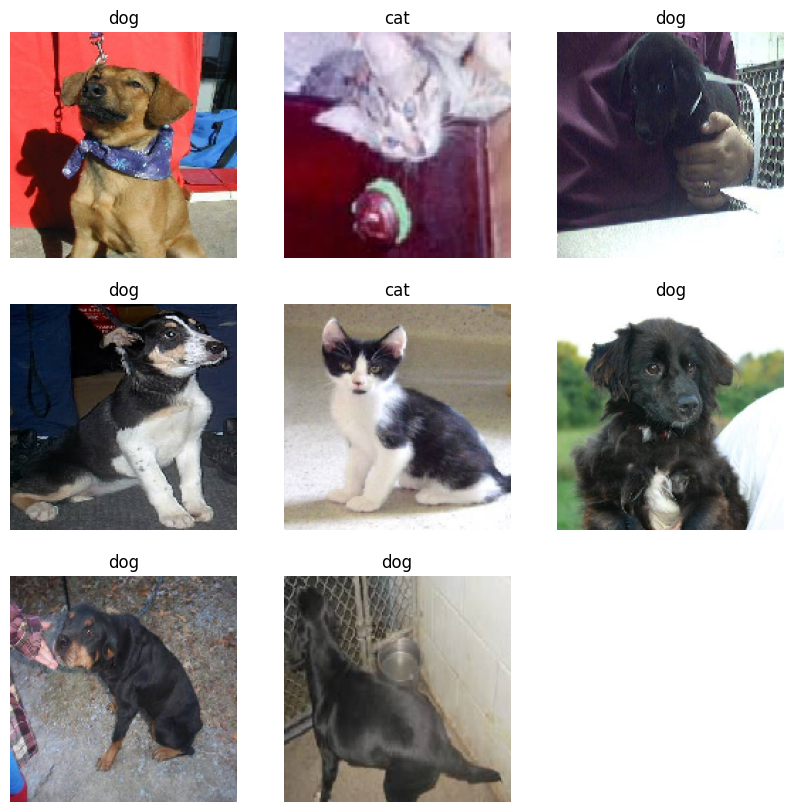

In [4]:
import matplotlib.pyplot as plt
import numpy as np

images, labels = next(train_data)

plt.figure(figsize=(10,10))
for i in range(len(images)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    class_idx = np.argmax(labels[i])
    class_name = list(train_data.class_indices.keys())[class_idx]
    plt.title(class_name)
    plt.axis("off")
plt.show()


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Input(shape=(*IMG_SIZE, 3)),

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation="relu"),
    Dense(2, activation="softmax")
])




2026-02-02 17:58:46.966381: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [6]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 158, 158, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 79, 79, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 77, 77, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,308,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,402,050 (20.61 MB)

 Trainable params: 5,402,050 (20.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=[early_stop]
)


Epoch 1/5


2000/2000 ━━━━━━━━━━━━━━━━━━━━ 299s 148ms/step - accuracy: 0.5756 - loss: 0.6717 - val_accuracy: 0.6658 - val_loss: 0.6378
Epoch 2/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 323s 162ms/step - accuracy: 0.6870 - loss: 0.6012 - val_accuracy: 0.7310 - val_loss: 0.5399
Epoch 3/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 339s 169ms/step - accuracy: 0.7629 - loss: 0.4889 - val_accuracy: 0.7660 - val_loss: 0.5059
Epoch 4/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 319s 160ms/step - accuracy: 0.8205 - loss: 0.3967 - val_accuracy: 0.7590 - val_loss: 0.5162
Epoch 5/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 320s 160ms/step - accuracy: 0.8808 - loss: 0.2851 - val_accuracy: 0.7667 - val_loss: 0.5723


In [8]:
from pathlib import Path
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- Paths (si el notebook está en /src) ---
ROOT = Path("..")
TEST_DIR = ROOT / "data" / "raw" / "test"
MODEL_PATH = ROOT / "models" / "best_model.keras"   # o "final_model.keras"

# --- Tamaño: debe coincidir con el entrenamiento ---
IMG_SIZE = (160, 160)   # si entrenaste con 160x160 (recomendado)
BATCH_SIZE = 8

print("📌 CWD:", Path.cwd())
print("📌 TEST_DIR existe?:", TEST_DIR.exists(), TEST_DIR.resolve())
print("📌 MODEL_PATH existe?:", MODEL_PATH.exists(), MODEL_PATH.resolve())

# Cargar modelo
model = tf.keras.models.load_model(MODEL_PATH)

# Generador test
test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    str(TEST_DIR),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# Evaluación
loss, acc = model.evaluate(test_data, verbose=1)
print(f"✅ TEST accuracy: {acc:.4f} | loss: {loss:.4f}")


📌 CWD: /workspaces/dori1888-intro-ml/src
📌 TEST_DIR existe?: True /workspaces/dori1888-intro-ml/data/raw/test
📌 MODEL_PATH existe?: True /workspaces/dori1888-intro-ml/models/best_model.keras
Found 5000 images belonging to 2 classes.
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.7908 - loss: 0.6405
✅ TEST accuracy: 0.7908 | loss: 0.6405


In [9]:
model.save("../models/image_classifier.keras")
